In [3]:
# Install dependencies inside the Antigravity kernel
!pip install ultralytics opencv-python numpy PyYAML

# Verify Apple Metal Performance Shaders (MPS)
import torch
if torch.backends.mps.is_available():
    print("SUCCESS: Apple Silicon MPS (Metal) detected and active!")
else:
    print("WARNING: MPS not found. Check the Antigravity kernel settings.")

SUCCESS: Apple Silicon MPS (Metal) detected and active!


In [4]:
from ultralytics import YOLO
import os

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/Users/abhashar/Library/Application Support/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [8]:
# Cell 2: Returniverse AI Engine - Training Loop
print(f"Current Working Directory: {os.getcwd()}")
print("--- INITIATING RETURNIVERSE AI ENGINE ON APPLE SILICON ---")

# 1. Load the YOLO11 Small model (Optimized for Hackathon Speed/Accuracy)
model = YOLO("yolo11s.pt") 

# 2. Launch the Training Sequence
results = model.train(
    data="./Dataset/data.yaml",
    epochs=50,             
    imgsz=640,             
    batch=16,              
    device="mps",          # Forces the MacBook Pro GPU to process the data
    
    # Online RAM Augmentations (Albumentations powered)
    mosaic=1.0,            
    mixup=0.2,             
    fliplr=0.5,            
    flipud=0.2,            
    hsv_v=0.4,             
    cls_pw=1.0,            
    
    project="returniverse_engine",
    name="production_run_v1"
)

print("Training sequence completed successfully.")

Current Working Directory: /Users/abhashar/abhay/AIGradding
--- INITIATING RETURNIVERSE AI ENGINE ON APPLE SILICON ---
Ultralytics 8.4.90 🚀 Python-3.13.14 torch-2.12.1 MPS (Apple M4 Pro)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=1.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./Dataset/data.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.2, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.2, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=prod

In [14]:
# verification_inference.py
from ultralytics import YOLO
import os

# 1. Map to the exact absolute path outputted by the training log
MODEL_PATH = "./runs/detect/returniverse_engine/production_run_v1-4/weights/best.pt"
TEST_IMAGE = "./test_image2.jpeg" # Update to an actual local image file

print("--- INITIALIZING MODEL BRAIN FOR VERIFICATION INFERENCE ---")
if not os.path.exists(MODEL_PATH):
    print(f"Error: Could not locate best.pt at {MODEL_PATH}")
else:
    # Load custom binaries
    model = YOLO(MODEL_PATH)
    
    if os.path.exists(TEST_IMAGE):
        # Execute forward pass inference
        results = model.predict(source=TEST_IMAGE, conf=0.25, save=True)
        
        print("\n--- INFERENCE CORRELATION MATRIX RESULTS ---")
        detected_boxes = results[0].boxes
        
        for box in detected_boxes:
            class_id = int(box.cls[0].item())
            confidence = box.conf[0].item()
            coordinates = box.xyxy[0].tolist()
            
            print(f"Detected Class ID: {class_id} | Confidence: {confidence:.2%}")
            print(f"Bounding Box Coordinates [X1, Y1, X2, Y2]: {[round(c,1) for c in coordinates]}")
            print("-" * 50)
            
        print(f"Visualized target image saved to: {results[0].save_dir}")
    else:
        print(f"Verification halted: Place a test photo at {TEST_IMAGE} to view box matrix tensors.")

--- INITIALIZING MODEL BRAIN FOR VERIFICATION INFERENCE ---

image 1/1 /Users/abhashar/abhay/AIGradding/test_image2.jpeg: 480x640 2 cracks, 1 dent, 1 scratch, 47.3ms
Speed: 0.9ms preprocess, 47.3ms inference, 0.5ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /Users/abhashar/abhay/runs/detect/predict-2

--- INFERENCE CORRELATION MATRIX RESULTS ---
Detected Class ID: 1 | Confidence: 47.45%
Bounding Box Coordinates [X1, Y1, X2, Y2]: [115.7, 190.9, 1516.3, 883.7]
--------------------------------------------------
Detected Class ID: 0 | Confidence: 46.99%
Bounding Box Coordinates [X1, Y1, X2, Y2]: [109.6, 207.0, 1004.6, 880.3]
--------------------------------------------------
Detected Class ID: 0 | Confidence: 37.47%
Bounding Box Coordinates [X1, Y1, X2, Y2]: [130.7, 189.2, 1538.4, 886.4]
--------------------------------------------------
Detected Class ID: 2 | Confidence: 25.52%
Bounding Box Coordinates [X1, Y1, X2, Y2]: [1110.7, 290.0, 1314.0, 398.8]
----------------


image 1/1 /Users/abhashar/abhay/AIGradding/test_image2.jpeg: 480x640 2 cracks, 1 dent, 1 scratch, 44.1ms
Speed: 0.7ms preprocess, 44.1ms inference, 0.5ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /Users/abhashar/abhay/AIGradding/runs/detect/predict

--- DETECTION VISUALIZATION ---
Loading visualized image from: /Users/abhashar/abhay/AIGradding/runs/detect/predict/test_image2.jpg


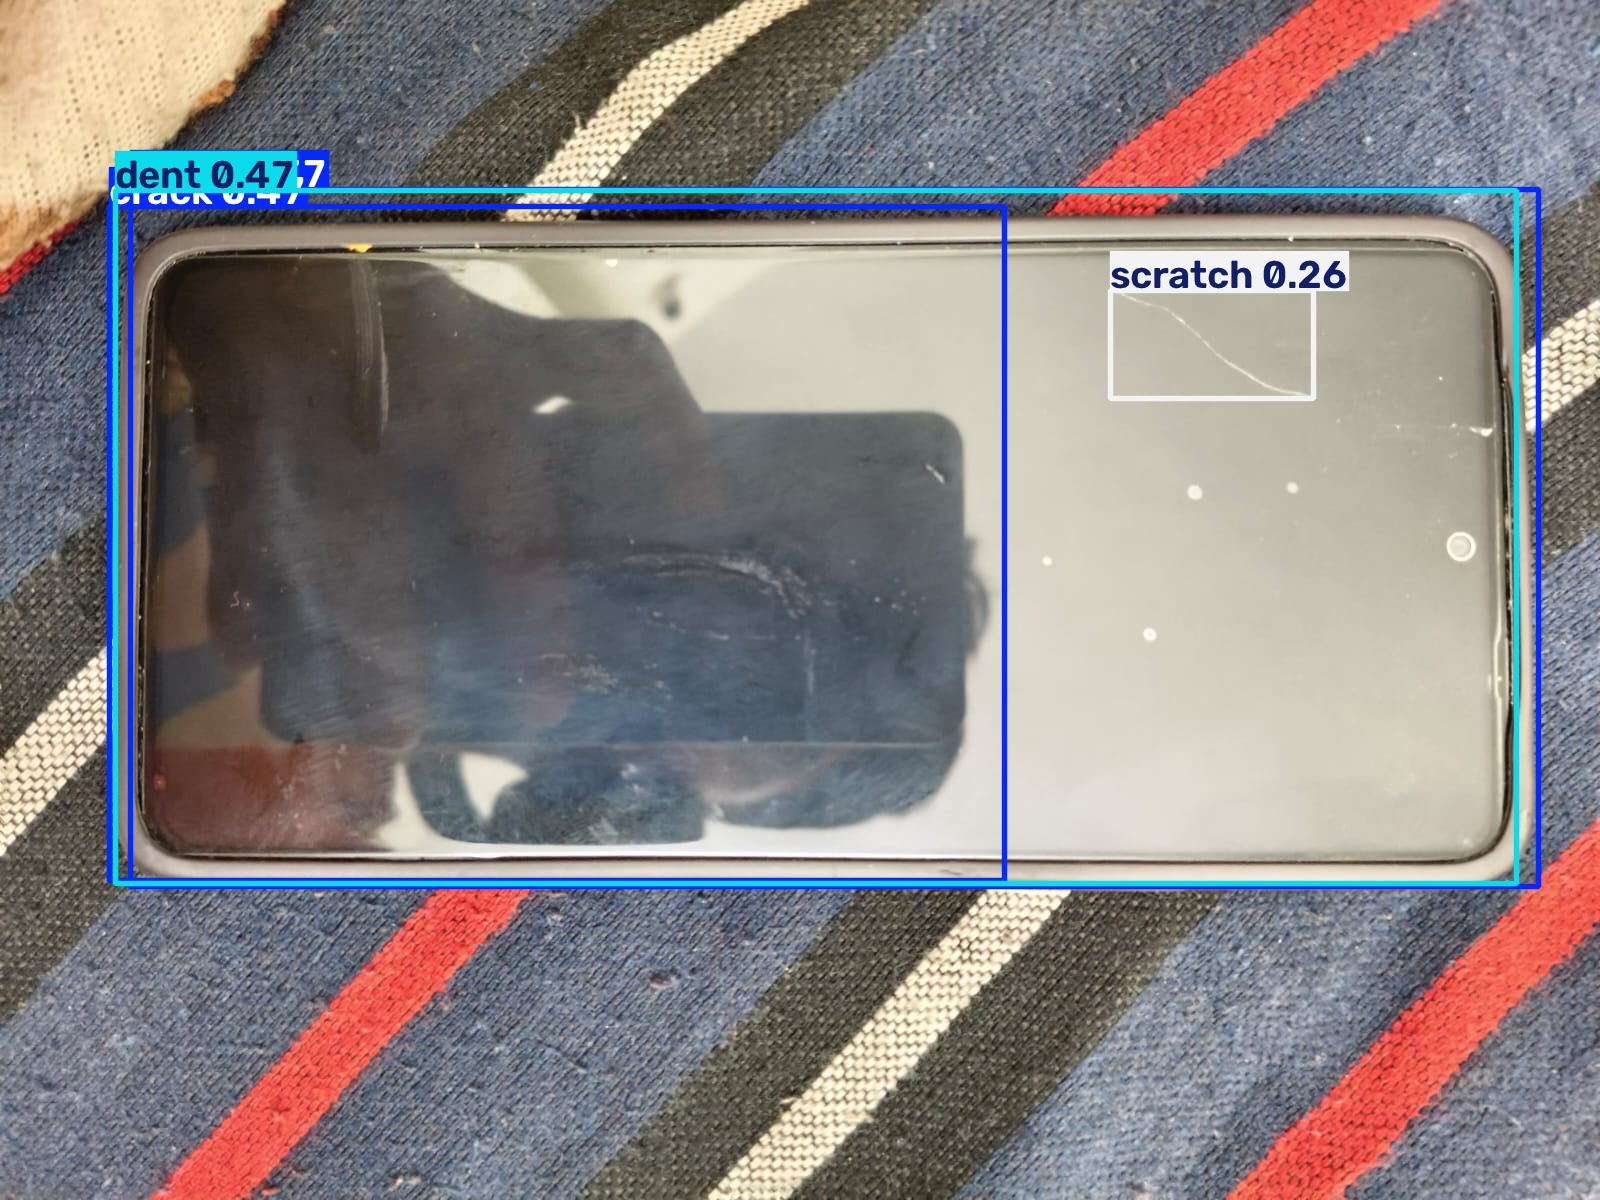

In [16]:
import os
import glob
from IPython.display import display, Image
from ultralytics import YOLO

# 1. Load the trained model
model = YOLO("./runs/detect/returniverse_engine/production_run_v1-4/weights/best.pt")

# 2. Set the path to your test image
image_path = "test_image2.jpeg"

# 3. Run prediction (Force the absolute path to your local AIGradding folder)
project_dir = os.path.abspath("./runs/detect")
results = model.predict(
    source=image_path,
    conf=0.25, 
    save=True,              
    project=project_dir, 
    name="predict",
    exist_ok=True
)

# 4. Find where YOLO saved the image (Handles the .jpeg -> .jpg conversion automatically)
save_dir = results[0].save_dir
search_pattern = os.path.join(save_dir, "test_image2.*")
saved_files = glob.glob(search_pattern)

if saved_files:
    saved_image_path = saved_files[0]
    print("\n--- DETECTION VISUALIZATION ---")
    print(f"Loading visualized image from: {saved_image_path}")
    
    # 5. Show the image directly in the Notebook!
    display(Image(filename=saved_image_path, width=800))
else:
    print(f"Error: Could not find the saved image in {save_dir}")


In [3]:
!pip install "transformers==4.57.6"

In [4]:
import transformers; transformers.__version__

'4.57.6'

In [10]:
pip install ipywidgets

   ---------------------------------------- 0.0/914.9 kB ? eta -:--:--
   ---------------------------------------- 914.9/914.9 kB 21.5 MB/s  0:00:00
   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   ---------------------------------------- 2.2/2.2 MB 32.6 MB/s  0:00:00

   ---------------------------------------- 0/3 [widgetsnbextension]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------- ------------- 2/3 [ipywidgets]
   -------------------------

--- INITIALIZING MOONDREAM ON APPLE SILICON ---
Cleared stale remote-code cache.
--- STAGE 1: DOWNLOADING WEIGHTS (watch the bars below) ---


Fetching 22 files: 100%|██████████| 22/22 [00:00<00:00, 61109.06it/s]



Downloaded to: /Users/abhashar/.cache/huggingface/hub/models--vikhyatk--moondream2/snapshots/92d3d73b6fd61ab84d9fe093a9c7fd8c04bf2c0d
Total on disk: 7141.9 MB in 0.5s

--- STAGE 2: LOADING MODEL INTO MEMORY ---


PhiForCausalLM has generative capabilities, as `prepare_inputs_for_generation` is explicitly defined. However, it doesn't directly inherit from `GenerationMixin`. From 👉v4.50👈 onwards, `PreTrainedModel` will NOT inherit from `GenerationMixin`, and this model will lose the ability to call `generate` and other related functions.
  - If you're using `trust_remote_code=True`, you can get rid of this warning by loading the model with an auto class. See https://huggingface.co/docs/transformers/en/model_doc/auto#auto-classes
  - If you are the owner of the model architecture code, please modify your model class such that it inherits from `GenerationMixin` (after `PreTrainedModel`, otherwise you'll get an exception).
  - If you are not the owner of the model architecture class, please contact the model code owner to update it.



Hardware set to: MPS
Moving model to device (can take 10-30s the first time)...

--- STAGE 3: RUNNING SEMANTIC INFERENCE ---
(First call is slowest — MPS compiles kernels on the first pass.)
Inference failed with error: 'PhiForCausalLM' object has no attribute 'generate'


In [6]:
pip install huggingface_hub

Note: you may need to restart the kernel to use updated packages.


In [10]:
# Serverless Moondream VQA Engine
# Lead Developer: Abhay Sharma (Scholar ID: 2312131)

import base64
from huggingface_hub import InferenceClient

# Initialize the Hugging Face cloud client
# Replace 'YOUR_HF_API_KEY' with a valid Hugging Face access token (starts with 'hf_')
client = InferenceClient(
    model="vikhyatk/moondream2",
    token="YOUR_HF_TOKEN"
)

def encode_image(image_path):
    """Converts the local image into a Base64 string for API transmission."""
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode('utf-8')

def query_item_context_api(image_path, question):
    """Passes the image and business logic question to the remote VLM."""
    try:
        base64_img = encode_image(image_path)
        image_url = f"data:image/jpeg;base64,{base64_img}"
        
        # Modern Vision-Language Models utilize the chat_completion array structure
        messages = [
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": question},
                    {"type": "image_url", "image_url": {"url": image_url}}
                ]
            }
        ]
        
        # Execute the remote API call
        response = client.chat_completion(
            messages=messages, 
            max_tokens=100
        )
        
        # Extract and return the plain text answer
        return response.choices[0].message.content
        
    except Exception as e:
        return f"Cloud Inference failed with error: {e}"

# Verification Execution
if __name__ == "__main__":
    # Ensure this file exists in the directory before running
    test_image = "test_image.jpeg" 
    test_question = "Are the original paper retail tags still attached?"
    
    print("--- TRANSMITTING SECURE API REQUEST TO HUGGING FACE ---")
    result = query_item_context_api(test_image, test_question)
    print(f"API Response: {result}")

--- TRANSMITTING SECURE API REQUEST TO HUGGING FACE ---
API Response: Cloud Inference failed with error: 


In [1]:
# robust_downloader.py
# Developer: Abhay Sharma (Scholar ID: 2312131)

from huggingface_hub import snapshot_download

print("--- INITIATING SECURE CHUNKED DOWNLOAD ---")
try:
    # This function automatically resumes if the network drops
    local_path = snapshot_download(
        repo_id="vikhyatk/moondream2",
        revision="2024-05-08",
        local_dir="./local_moondream", # Saves directly to the working directory
        max_workers=4
    )
    print(f"SUCCESS: Model weights safely downloaded to {local_path}")
except Exception as e:
    print(f"Download encountered an error: {e}")

--- INITIATING SECURE CHUNKED DOWNLOAD ---


Fetching 18 files:   0%|          | 0/18 [00:00<?, ?it/s]

.gitattributes: 0.00B [00:00, ?B/s]

README.md: 0.00B [00:00, ?B/s]

generation_config.json:   0%|          | 0.00/69.0 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.72G [00:00<?, ?B/s]

moondream2-mmproj-f16.gguf:   0%|          | 0.00/910M [00:00<?, ?B/s]

moondream2-text-model-f16.gguf:   0%|          | 0.00/2.84G [00:00<?, ?B/s]

versions.txt:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

SUCCESS: Model weights safely downloaded to D:\New folder (3)\Amazon_HackOn\Grading-pipeline-main\local_moondream


In [6]:
# Patched Moondream Initializer
# Fixes compatibility issues with transformers >= 4.50 (GenerationMixin) and adds modern .query() syntax

import torch
from transformers import AutoTokenizer

def initialize_patched_moondream():
    # 1. Patch PhiForCausalLM bases at runtime to include GenerationMixin
    import local_moondream.modeling_phi as modeling_phi
    from transformers.generation import GenerationMixin
    
    if GenerationMixin not in modeling_phi.PhiForCausalLM.__bases__:
        modeling_phi.PhiForCausalLM.__bases__ = (modeling_phi.PhiPreTrainedModel, GenerationMixin)
        print("Successfully patched PhiForCausalLM with GenerationMixin compatibility.")

    # 2. Inject modern .query() syntax helper into Moondream
    from local_moondream.moondream import Moondream
    
    def custom_query(self, image, question):
        enc_image = self.encode_image(image)
        ans = self.answer_question(enc_image, question, self.tokenizer)
        return {"answer": ans}
        
    Moondream.query = custom_query
    
    # 3. Load configuration, model, and tokenizer from local snapshot path
    from local_moondream.configuration_moondream import MoondreamConfig
    
    config = MoondreamConfig.from_pretrained("./local_moondream")
    model = Moondream.from_pretrained(
        "./local_moondream",
        config=config,
        trust_remote_code=True
    )
    tokenizer = AutoTokenizer.from_pretrained("./local_moondream")
    model.tokenizer = tokenizer
    
    # 4. Move model to the active device (MPS for Mac GPU, CUDA, or CPU)
    device = "mps" if torch.backends.mps.is_available() else "cpu"
    if torch.cuda.is_available():
        device = "cuda"
    model = model.to(device)
    print(f"Model loaded and running on hardware device: {device}")
    
    return model, tokenizer

In [3]:
# Execution and Verification Block
# Lead Developer: Abhay Sharma (Scholar ID: 2312131)

# Patched Moondream Initializer
# Fixes compatibility issues with transformers >= 4.50 (GenerationMixin) and adds modern .query() syntax

import torch
from transformers import AutoTokenizer

def initialize_patched_moondream():
    # 1. Patch PhiForCausalLM bases at runtime to include GenerationMixin
    import local_moondream.modeling_phi as modeling_phi
    from transformers.generation import GenerationMixin
    
    if GenerationMixin not in modeling_phi.PhiForCausalLM.__bases__:
        modeling_phi.PhiForCausalLM.__bases__ = (modeling_phi.PhiPreTrainedModel, GenerationMixin)
        print("Successfully patched PhiForCausalLM with GenerationMixin compatibility.")

    # 2. Inject modern .query() syntax helper into Moondream
    from local_moondream.moondream import Moondream
    
    def custom_query(self, image, question):
        enc_image = self.encode_image(image)
        ans = self.answer_question(enc_image, question, self.tokenizer)
        return {"answer": ans}
        
    Moondream.query = custom_query
    
    # 3. Load configuration, model, and tokenizer from local snapshot path
    from local_moondream.configuration_moondream import MoondreamConfig
    
    config = MoondreamConfig.from_pretrained("./local_moondream")
    model = Moondream.from_pretrained(
        "./local_moondream",
        config=config,
        trust_remote_code=True
    )
    tokenizer = AutoTokenizer.from_pretrained("./local_moondream")
    model.tokenizer = tokenizer
    
    # 4. Move model to the active device (MPS for Mac GPU, CUDA, or CPU)
    device = "mps" if torch.backends.mps.is_available() else "cpu"
    if torch.cuda.is_available():
        device = "cuda"
    model = model.to(device)
    print(f"Model loaded and running on hardware device: {device}")
    
    return model, tokenizer
from PIL import Image
import time

# 1. Execute the function to initialize the engines
print("--- INITIALIZING PATCHED MOONDREAM ENGINE ---")
model, tokenizer = initialize_patched_moondream()
print("Success: Model loaded into Apple Silicon memory.")

# 2. Define a test image and question
# Ensure a sample image named 'sample_image.jpg' is in the working directory
test_image_path = "test_image.jpeg"
question = "Describe the condition of the main object in this image."

try:
    print("\n--- RUNNING SEMANTIC INFERENCE ---")
    start_time = time.time()
    
    # 3. Load the image and query the model
    image = Image.open(test_image_path).convert("RGB")
    
    # Note: The patched architecture utilizes the updated .query() syntax
    result = model.query(image, question)["answer"]
    
    execution_time = time.time() - start_time
    print(f"Prompt: '{question}'")
    print(f"Response: {result}")
    print(f"Inference Latency: {execution_time:.2f} seconds")

except FileNotFoundError:
    print(f"\nERROR: Could not find '{test_image_path}'. Please place a test image in the directory.")
except Exception as e:
    print(f"\nInference Error: {e}")

--- INITIALIZING PATCHED MOONDREAM ENGINE ---


: 